# Arm Action Detection from Sensor Data

This notebook analyzes all ADL recordings to determine which sensors and values best discriminate arm actions (columns `LL_Left_Arm` and `LL_Right_Arm`).

## Strategy
We focus on three sensor families:
1. **Body-worn IMU gyroscopes** (lower and upper arm) – measure rotation speed and axis.
2. **Body-worn accelerometers** (hand, wrist, upper arm) – encode arm posture through gravity direction.
3. **Object accelerometers** – confirm which object is being acted upon.

Gyroscopes are the primary discriminator because different arm actions produce distinctly different rotation speeds and axes.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from utils import load_all_adl

pd.set_option('display.float_format', '{:.1f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

df = load_all_adl()
print(f'Loaded {len(df):,} rows across {df["subject"].nunique()} subjects and {df["recording"].nunique()} recordings.')
print(f'Left arm actions:  {sorted(df["LL_Left_Arm"].dropna().unique())}')
print(f'Right arm actions: {sorted(df["LL_Right_Arm"].dropna().unique())}')

Loaded 644,635 rows across 4 subjects and 20 recordings.
Left arm actions:  ['bite', 'clean', 'close', 'cut', 'lock', 'move', 'open', 'reach', 'release', 'sip', 'unlock']
Right arm actions: ['bite', 'clean', 'close', 'cut', 'lock', 'move', 'open', 'reach', 'release', 'sip', 'spread', 'stir', 'unlock']


## 1. Derive key features

We compute scalar magnitudes from the IMU gyroscopes and accelerometers on both arms.

**Gyroscope magnitude** = √(gyroX² + gyroY² + gyroZ²)  
This captures total rotational speed regardless of axis. Units are approximately deg/s.

**Acceleration magnitude** = √(accX² + accY² + accZ²)  
At rest this equals ~1000 (the gravity vector in mg units). Deviation above 1000 reflects dynamic motion.

In [2]:
# ── Left arm features ──────────────────────────────────────────────────────────
df['L_la_gyro_mag'] = np.sqrt(df['InertialMeasurementUnit_LLA_gyroX']**2 +
                               df['InertialMeasurementUnit_LLA_gyroY']**2 +
                               df['InertialMeasurementUnit_LLA_gyroZ']**2)

df['L_ua_gyro_mag'] = np.sqrt(df['InertialMeasurementUnit_LUA_gyroX']**2 +
                               df['InertialMeasurementUnit_LUA_gyroY']**2 +
                               df['InertialMeasurementUnit_LUA_gyroZ']**2)

df['L_hand_acc_mag'] = np.sqrt(df['Accelerometer_LH_accX']**2 +
                                df['Accelerometer_LH_accY']**2 +
                                df['Accelerometer_LH_accZ']**2)

df['L_wrist_acc_mag'] = np.sqrt(df['Accelerometer_LWR_accX']**2 +
                                 df['Accelerometer_LWR_accY']**2 +
                                 df['Accelerometer_LWR_accZ']**2)

# ── Right arm features ─────────────────────────────────────────────────────────
df['R_la_gyro_mag'] = np.sqrt(df['InertialMeasurementUnit_RLA_gyroX']**2 +
                               df['InertialMeasurementUnit_RLA_gyroY']**2 +
                               df['InertialMeasurementUnit_RLA_gyroZ']**2)

df['R_ua_gyro_mag'] = np.sqrt(df['InertialMeasurementUnit_RUA_gyroX']**2 +
                               df['InertialMeasurementUnit_RUA_gyroY']**2 +
                               df['InertialMeasurementUnit_RUA_gyroZ']**2)

df['R_hand_acc_mag'] = np.sqrt(df['Accelerometer_RH_accX']**2 +
                                df['Accelerometer_RH_accY']**2 +
                                df['Accelerometer_RH_accZ']**2)

df['R_wrist_acc_mag'] = np.sqrt(df['Accelerometer_RWR_accX']**2 +
                                 df['Accelerometer_RWR_accY']**2 +
                                 df['Accelerometer_RWR_accZ']**2)

# ── Absolute gyro per axis (for axis dominance analysis) ─────────────────────
for side, arm in [('L', 'LLA'), ('L', 'LUA'), ('R', 'RLA'), ('R', 'RUA')]:
    pfx = f'InertialMeasurementUnit_{arm}_gyro'
    label = f'{side}_{arm}_'
    for ax in ['X', 'Y', 'Z']:
        df[f'{label}abs{ax}'] = df[f'{pfx}{ax}'].abs()

print('Feature columns created.')

Feature columns created.


In [4]:
for c in df.columns:
    print(c)

MILLISEC
Accelerometer_RKN^_accX
Accelerometer_RKN^_accY
Accelerometer_RKN^_accZ
Accelerometer_HIP_accX
Accelerometer_HIP_accY
Accelerometer_HIP_accZ
Accelerometer_LUA^_accX
Accelerometer_LUA^_accY
Accelerometer_LUA^_accZ
Accelerometer_RUA__accX
Accelerometer_RUA__accY
Accelerometer_RUA__accZ
Accelerometer_LH_accX
Accelerometer_LH_accY
Accelerometer_LH_accZ
Accelerometer_BACK_accX
Accelerometer_BACK_accY
Accelerometer_BACK_accZ
Accelerometer_RKN__accX
Accelerometer_RKN__accY
Accelerometer_RKN__accZ
Accelerometer_RWR_accX
Accelerometer_RWR_accY
Accelerometer_RWR_accZ
Accelerometer_RUA^_accX
Accelerometer_RUA^_accY
Accelerometer_RUA^_accZ
Accelerometer_LUA__accX
Accelerometer_LUA__accY
Accelerometer_LUA__accZ
Accelerometer_LWR_accX
Accelerometer_LWR_accY
Accelerometer_LWR_accZ
Accelerometer_RH_accX
Accelerometer_RH_accY
Accelerometer_RH_accZ
InertialMeasurementUnit_BACK_accX
InertialMeasurementUnit_BACK_accY
InertialMeasurementUnit_BACK_accZ
InertialMeasurementUnit_BACK_gyroX
InertialMea

## 2. Gyroscope magnitude statistics per arm action

The lower-arm (forearm) IMU gyroscope magnitude is the single best discriminator.
The table below shows **mean ± std** of this magnitude for each labelled action.

In [3]:
LEFT_FEAT  = ['L_la_gyro_mag', 'L_ua_gyro_mag', 'L_hand_acc_mag', 'L_wrist_acc_mag']
RIGHT_FEAT = ['R_la_gyro_mag', 'R_ua_gyro_mag', 'R_hand_acc_mag', 'R_wrist_acc_mag']

def action_stats(arm_col, feat_cols):
    g = df.dropna(subset=[arm_col]).groupby(arm_col)
    mean = g[feat_cols].mean()
    std  = g[feat_cols].std()
    count = g[feat_cols[0]].count().rename('n_frames')
    combined = mean.copy()
    for c in feat_cols:
        combined[c] = mean[c].map('{:.0f}'.format) + ' ± ' + std[c].map('{:.0f}'.format)
    combined.insert(0, 'n_frames', count)
    return combined

print('=== LEFT ARM: sensor statistics per action ===')
display(action_stats('LL_Left_Arm', LEFT_FEAT))

print('\n=== RIGHT ARM: sensor statistics per action ===')
display(action_stats('LL_Right_Arm', RIGHT_FEAT))

=== LEFT ARM: sensor statistics per action ===


,n_frames,L_la_gyro_mag,L_ua_gyro_mag,L_hand_acc_mag,L_wrist_acc_mag
LL_Left_Arm,,,,,
bite,3134,331 ± 516,182 ± 273,984 ± 125,1002 ± 97
clean,844,2373 ± 1151,1706 ± 863,1222 ± 489,1136 ± 369
close,10819,918 ± 704,842 ± 550,1103 ± 219,1043 ± 157
cut,728,313 ± 393,278 ± 396,1053 ± 162,1014 ± 78
lock,70,698 ± 600,353 ± 223,982 ± 267,1016 ± 176
move,82616,707 ± 670,585 ± 565,1033 ± 165,1017 ± 134
open,10571,884 ± 698,814 ± 546,1087 ± 198,1027 ± 144
reach,16554,1202 ± 979,952 ± 735,1079 ± 208,1054 ± 1682
release,9851,1560 ± 1225,1194 ± 900,1107 ± 264,1044 ± 194



=== RIGHT ARM: sensor statistics per action ===


,n_frames,R_la_gyro_mag,R_ua_gyro_mag,R_hand_acc_mag,R_wrist_acc_mag
LL_Right_Arm,,,,,
bite,3804,220 ± 319,137 ± 180,1021 ± 87,1006 ± 104
clean,5160,2713 ± 1597,2151 ± 1225,1508 ± 627,1301 ± 452
close,14536,868 ± 756,704 ± 493,1082 ± 264,1041 ± 212
cut,9808,415 ± 370,463 ± 375,1067 ± 170,1025 ± 158
lock,1161,1597 ± 1600,1012 ± 811,1143 ± 393,1064 ± 280
move,113108,896 ± 735,700 ± 604,1052 ± 179,1019 ± 152
open,15778,859 ± 736,740 ± 510,1082 ± 262,1028 ± 198
reach,35030,1190 ± 960,933 ± 711,1086 ± 260,1038 ± 194
release,20550,1733 ± 1530,1255 ± 1033,1106 ± 305,1045 ± 221


## 3. Box plots: lower-arm gyroscope by action

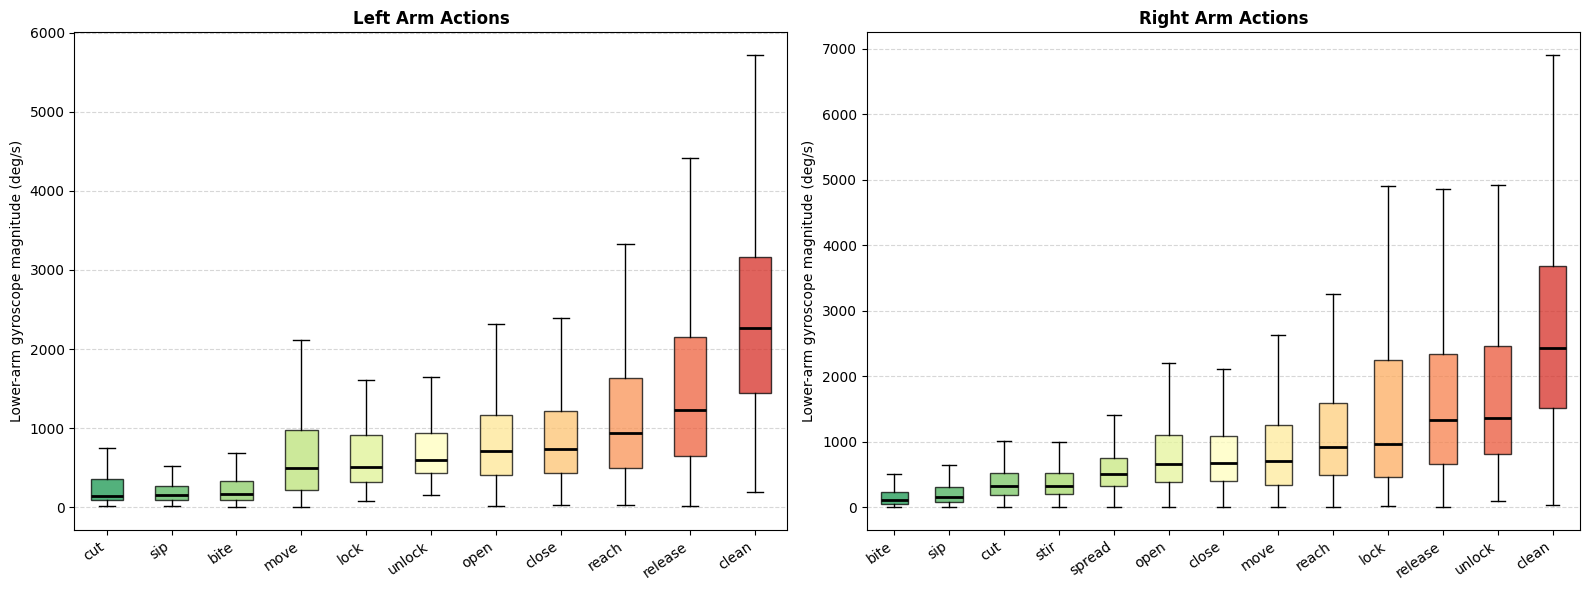

In [35]:
def gyro_boxplot(arm_label_col, gyro_col, title, ax):
    sub = df.dropna(subset=[arm_label_col])[[arm_label_col, gyro_col]].copy()
    # order actions by median gyro
    order = sub.groupby(arm_label_col)[gyro_col].median().sort_values().index.tolist()
    data  = [sub.loc[sub[arm_label_col] == a, gyro_col].values for a in order]
    filtered_data = [arr[~np.isnan(arr)] for arr in data]
    bp = ax.boxplot(filtered_data, vert=True, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(order)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(order)+1))
    ax.set_xticklabels(order, rotation=35, ha='right', fontsize=10)
    ax.set_ylabel('Lower-arm gyroscope magnitude (deg/s)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
gyro_boxplot('LL_Left_Arm',  'L_la_gyro_mag', 'Left Arm Actions',  axes[0])
gyro_boxplot('LL_Right_Arm', 'R_la_gyro_mag', 'Right Arm Actions', axes[1])
plt.tight_layout()
plt.savefig('gyro_by_action.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Gyroscope magnitude thresholds per action

We define approximate threshold bands for the **lower-arm IMU gyroscope magnitude** that can serve as detectors.

In [5]:
def quantile_table(arm_col, gyro_col):
    g = df.dropna(subset=[arm_col]).groupby(arm_col)[gyro_col]
    tbl = g.quantile([0.25, 0.50, 0.75]).unstack()
    tbl.columns = ['Q25', 'Median', 'Q75']
    tbl['Mean'] = g.mean()
    tbl = tbl[['Mean','Q25','Median','Q75']].sort_values('Median')
    return tbl.map(lambda x: f'{x:.0f}')

print('=== LEFT ARM: lower-arm gyro quantiles per action ===')
display(quantile_table('LL_Left_Arm', 'L_la_gyro_mag'))

print('\n=== RIGHT ARM: lower-arm gyro quantiles per action ===')
display(quantile_table('LL_Right_Arm', 'R_la_gyro_mag'))

=== LEFT ARM: lower-arm gyro quantiles per action ===


,Mean,Q25,Median,Q75
LL_Left_Arm,,,,
cut,313,97,145,359
sip,282,98,151,267
bite,331,95,165,334
move,707,219,492,980
lock,698,316,508,920
unlock,1077,429,604,944
open,884,404,715,1169
close,918,433,735,1217
reach,1202,497,938,1632



=== RIGHT ARM: lower-arm gyro quantiles per action ===


,Mean,Q25,Median,Q75
LL_Right_Arm,,,,
bite,220,59,119,242
sip,263,84,164,312
cut,415,195,326,525
stir,428,203,327,519
spread,601,319,511,758
open,859,381,664,1111
close,868,405,679,1089
move,896,347,704,1261
reach,1190,500,922,1600


## 5. Gyroscope axis dominance per action

Beyond the total magnitude, *which axis* carries the rotation indicates the type of motion:
- **X axis**: pronation/supination (forearm twisting, e.g., turning a key)
- **Y axis**: lateral sweep (side-to-side, e.g., scrubbing a table)
- **Z axis**: flexion/extension or forward-back roll

We show the fraction of total absolute gyro in each axis.

In [6]:
def axis_fractions(arm_col, arm_code):
    pfx = f'InertialMeasurementUnit_{arm_code}_gyro'
    sub = df.dropna(subset=[arm_col])[[arm_col, pfx+'X', pfx+'Y', pfx+'Z']].copy()
    for ax in ['X','Y','Z']:
        sub[ax+'_abs'] = sub[pfx+ax].abs()
    sub['total_abs'] = sub[['X_abs','Y_abs','Z_abs']].sum(axis=1)
    for ax in ['X','Y','Z']:
        sub[ax+'_frac'] = sub[ax+'_abs'] / sub['total_abs']
    out = sub.groupby(arm_col)[['X_frac','Y_frac','Z_frac']].mean()
    out.columns = [f'{arm_code}_gyro_fracX', f'{arm_code}_gyro_fracY', f'{arm_code}_gyro_fracZ']
    return out.map(lambda x: f'{x:.2f}')

print('=== LEFT LOWER ARM gyro axis fractions ===')
display(axis_fractions('LL_Left_Arm', 'LLA'))

print('\n=== RIGHT LOWER ARM gyro axis fractions ===')
display(axis_fractions('LL_Right_Arm', 'RLA'))

=== LEFT LOWER ARM gyro axis fractions ===


,LLA_gyro_fracX,LLA_gyro_fracY,LLA_gyro_fracZ
LL_Left_Arm,,,
bite,0.42,0.28,0.31
clean,0.31,0.43,0.26
close,0.39,0.34,0.27
cut,0.43,0.23,0.34
lock,0.53,0.22,0.24
move,0.36,0.33,0.31
open,0.38,0.34,0.28
reach,0.41,0.30,0.28
release,0.38,0.33,0.28



=== RIGHT LOWER ARM gyro axis fractions ===


,RLA_gyro_fracX,RLA_gyro_fracY,RLA_gyro_fracZ
LL_Right_Arm,,,
bite,0.33,0.27,0.40
clean,0.30,0.33,0.36
close,0.39,0.28,0.33
cut,0.37,0.33,0.30
lock,0.52,0.24,0.24
move,0.34,0.32,0.33
open,0.34,0.33,0.33
reach,0.38,0.30,0.32
release,0.37,0.31,0.33


## 6. Hand accelerometer directionality (arm posture)

A stationary accelerometer reads the gravity vector, telling us which direction "down" is relative to the sensor — i.e., the **orientation/posture** of that body segment.

We look at the **mean signed acceleration on each axis** to determine typical arm posture during each action.

In [7]:
left_acc_axes  = ['Accelerometer_LH_accX','Accelerometer_LH_accY','Accelerometer_LH_accZ',
                   'Accelerometer_LWR_accX','Accelerometer_LWR_accY','Accelerometer_LWR_accZ']
right_acc_axes = ['Accelerometer_RH_accX','Accelerometer_RH_accY','Accelerometer_RH_accZ',
                   'Accelerometer_RWR_accX','Accelerometer_RWR_accY','Accelerometer_RWR_accZ']

print('=== LEFT ARM: mean hand/wrist acceleration per axis per action ===')
display(df.dropna(subset=['LL_Left_Arm']).groupby('LL_Left_Arm')[left_acc_axes].mean()
          .map(lambda x: f'{x:.0f}'))

print('\n=== RIGHT ARM: mean hand/wrist acceleration per axis per action ===')
display(df.dropna(subset=['LL_Right_Arm']).groupby('LL_Right_Arm')[right_acc_axes].mean()
          .map(lambda x: f'{x:.0f}'))

=== LEFT ARM: mean hand/wrist acceleration per axis per action ===


,Accelerometer_LH_accX,Accelerometer_LH_accY,Accelerometer_LH_accZ,Accelerometer_LWR_accX,Accelerometer_LWR_accY,Accelerometer_LWR_accZ
LL_Left_Arm,,,,,,
bite,583,-663,-33,-200,-755,396
clean,573,726,-352,-332,501,767
close,463,699,-38,-455,517,359
cut,707,253,-185,-682,256,576
lock,649,273,652,-579,-103,643
move,624,263,76,-597,116,389
open,487,662,-241,-438,523,439
reach,517,528,-74,-474,398,453
release,546,591,-49,-449,425,446



=== RIGHT ARM: mean hand/wrist acceleration per axis per action ===


,Accelerometer_RH_accX,Accelerometer_RH_accY,Accelerometer_RH_accZ,Accelerometer_RWR_accX,Accelerometer_RWR_accY,Accelerometer_RWR_accZ
LL_Right_Arm,,,,,,
bite,-669,-640,-148,64,-650,367
clean,-763,550,-342,-179,555,597
close,-463,408,-103,-98,367,346
cut,-683,355,-478,-148,104,490
lock,-700,-34,-80,-45,215,462
move,-720,252,47,70,206,475
open,-423,444,-150,-127,333,383
reach,-636,458,-19,-87,342,403
release,-564,529,34,-68,431,372


## 7. Upper vs. lower arm gyroscope ratio

Actions that involve mainly wrist/forearm activity (stir, cut, spread) will show **lower-arm gyro >> upper-arm gyro**.  
Actions involving whole-arm motion (reach, clean) will show **both arms rotating at similar rates**.

In [8]:
def la_ua_ratio(arm_col, la_col, ua_col):
    sub = df.dropna(subset=[arm_col])[[arm_col, la_col, ua_col]].copy()
    sub['ratio_LA_over_UA'] = sub[la_col] / sub[ua_col].replace(0, np.nan)
    out = sub.groupby(arm_col)[[la_col, ua_col, 'ratio_LA_over_UA']].mean()
    out.columns = ['LA_gyro_mean', 'UA_gyro_mean', 'LA/UA_ratio']
    return out.sort_values('LA_gyro_mean').map(lambda x: f'{x:.1f}')

print('=== LEFT ARM: lower vs. upper arm gyro ratio ===')
display(la_ua_ratio('LL_Left_Arm', 'L_la_gyro_mag', 'L_ua_gyro_mag'))

print('\n=== RIGHT ARM: lower vs. upper arm gyro ratio ===')
display(la_ua_ratio('LL_Right_Arm', 'R_la_gyro_mag', 'R_ua_gyro_mag'))

=== LEFT ARM: lower vs. upper arm gyro ratio ===


,LA_gyro_mean,UA_gyro_mean,LA/UA_ratio
LL_Left_Arm,,,
sip,281.5,192.0,1.5
cut,313.2,277.8,1.5
bite,330.8,182.1,2.4
lock,698.4,352.8,3.1
move,706.7,584.7,1.6
open,883.6,814.0,1.3
close,918.4,842.4,1.4
unlock,1077.1,837.3,1.5
reach,1202.1,952.1,1.5



=== RIGHT ARM: lower vs. upper arm gyro ratio ===


,LA_gyro_mean,UA_gyro_mean,LA/UA_ratio
LL_Right_Arm,,,
bite,220.1,137.1,1.9
sip,263.5,191.7,1.5
cut,414.9,463.0,1.2
stir,428.1,222.8,2.6
spread,600.9,568.4,1.2
open,859.3,740.0,1.3
close,868.0,703.9,1.5
move,896.3,699.8,1.6
reach,1190.5,933.1,1.6


## 8. Left vs. Right arm asymmetry for shared actions

Most subjects appear right-handed, so we expect the right arm to be more active for actions performed by both arms.

Left vs. Right lower-arm gyro for shared actions (higher = more active):


,Left_LA_gyro,Right_LA_gyro,Right_minus_Left,Right/Left_ratio
bite,331,220,-111,0.67
clean,2373,2713,341,1.14
close,918,868,-50,0.95
cut,313,415,102,1.32
move,707,896,190,1.27
open,884,859,-24,0.97
reach,1202,1190,-12,0.99
release,1560,1733,174,1.11
sip,282,263,-18,0.94


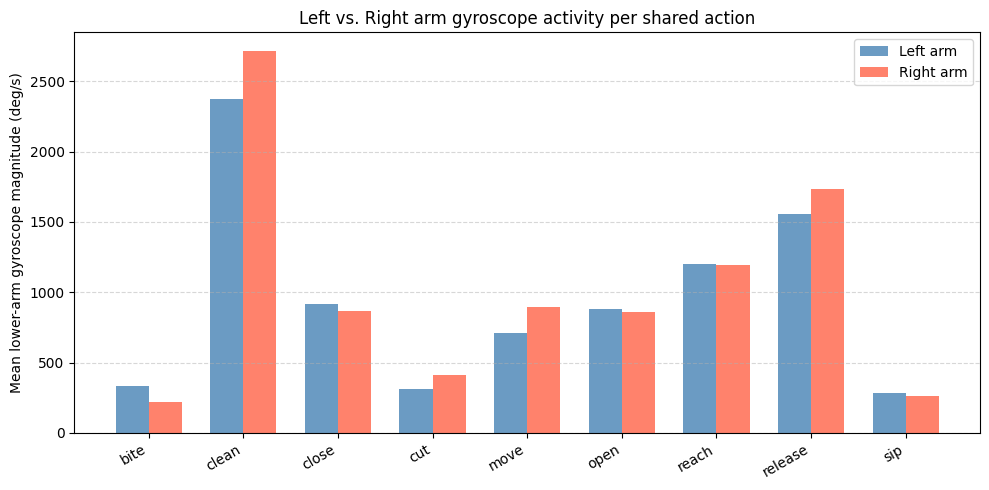

In [9]:
shared_actions = ['bite', 'clean', 'close', 'cut', 'move', 'open', 'reach', 'release', 'sip']

# Build side-by-side comparison
left_means  = df.dropna(subset=['LL_Left_Arm']).groupby('LL_Left_Arm')['L_la_gyro_mag'].mean()
right_means = df.dropna(subset=['LL_Right_Arm']).groupby('LL_Right_Arm')['R_la_gyro_mag'].mean()

compare = pd.DataFrame({
    'Left_LA_gyro':  left_means,
    'Right_LA_gyro': right_means,
}).loc[shared_actions].dropna()
compare['Right_minus_Left'] = compare['Right_LA_gyro'] - compare['Left_LA_gyro']
compare['Right/Left_ratio'] = (compare['Right_LA_gyro'] / compare['Left_LA_gyro']).map('{:.2f}'.format)

print('Left vs. Right lower-arm gyro for shared actions (higher = more active):')
display(compare.map(lambda x: f'{x:.0f}' if isinstance(x, float) else x))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare))
w = 0.35
ax.bar(x - w/2, compare['Left_LA_gyro'],  w, label='Left arm',  color='steelblue', alpha=0.8)
ax.bar(x + w/2, compare['Right_LA_gyro'], w, label='Right arm', color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=30, ha='right')
ax.set_ylabel('Mean lower-arm gyroscope magnitude (deg/s)')
ax.set_title('Left vs. Right arm gyroscope activity per shared action')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('left_vs_right_gyro.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Object sensor co-activation

When an arm is labelled with a specific action, we can check which **object accelerometers** show elevated motion — cross-validating the arm label with the object being manipulated.

In [10]:
# Compute magnitude for each portable object sensor
objects = ['CUP','GLASS','PLATE','KNIFE1','KNIFE2','SPOON','BREAD','SALAMI','CHEESE','MILK']
for obj in objects:
    cols = [f'Accelerometer_{obj}_accX', f'Accelerometer_{obj}_accX_2', f'Accelerometer_{obj}_accX_3']
    if all(c in df.columns for c in cols):
        df[f'{obj}_acc_mag'] = np.sqrt(df[cols[0]]**2 + df[cols[1]]**2 + df[cols[2]]**2)

obj_mag_cols = [f'{o}_acc_mag' for o in objects if f'{o}_acc_mag' in df.columns]

# Show which objects are most active during each right-arm action
# (only show object-specific deviations from each object's global mean)
obj_global_mean = df[obj_mag_cols].mean()

print('=== RIGHT ARM: object acc magnitude ABOVE global baseline per action ===')
right_obj = df.dropna(subset=['LL_Right_Arm']).groupby('LL_Right_Arm')[obj_mag_cols].mean()
excess = (right_obj - obj_global_mean).map(lambda x: f'{x:+.0f}')
display(excess)

print('\n=== LEFT ARM: object acc magnitude ABOVE global baseline per action ===')
left_obj = df.dropna(subset=['LL_Left_Arm']).groupby('LL_Left_Arm')[obj_mag_cols].mean()
excess_l = (left_obj - obj_global_mean).map(lambda x: f'{x:+.0f}')
display(excess_l)

=== RIGHT ARM: object acc magnitude ABOVE global baseline per action ===


,CUP_acc_mag,GLASS_acc_mag,PLATE_acc_mag,KNIFE1_acc_mag,KNIFE2_acc_mag,SPOON_acc_mag,BREAD_acc_mag,SALAMI_acc_mag,CHEESE_acc_mag,MILK_acc_mag
LL_Right_Arm,,,,,,,,,,
bite,-3,-13,-2,-3,-7,-2,-5,+1,-4,-2
clean,+14,+7,-13,-6,+1,-14,+8,-8,-8,-4
close,+3,+31,-2,+1,+2,-3,+3,-1,-0,+1
cut,-3,-13,+2,+24,-6,-2,-2,-3,-5,-2
lock,+5,+2,-4,-2,+0,-6,-0,-9,-4,-3
move,+1,-7,+0,+1,+1,-1,+2,+8,+1,+1
open,-2,-10,-1,+2,-0,-2,+1,-2,-1,-1
reach,+1,+13,-0,+2,+1,-1,+1,-2,+0,+1
release,+4,+11,-1,+1,+0,-3,+1,-2,-0,-1



=== LEFT ARM: object acc magnitude ABOVE global baseline per action ===


,CUP_acc_mag,GLASS_acc_mag,PLATE_acc_mag,KNIFE1_acc_mag,KNIFE2_acc_mag,SPOON_acc_mag,BREAD_acc_mag,SALAMI_acc_mag,CHEESE_acc_mag,MILK_acc_mag
LL_Left_Arm,,,,,,,,,,
bite,-3,-13,-1,-0,-5,-2,-8,+0,-1,-2
clean,+31,+19,-10,-10,-4,-11,-4,-5,-5,+1
close,-2,-10,-1,+1,-2,-4,-1,+1,+5,+13
cut,-4,-14,+6,+15,-1,+4,+1,-8,-3,-5
lock,-1,-8,-4,-4,+4,-4,+0,+3,-5,+2
move,-0,+7,+1,+3,+2,-2,+3,-0,+3,-1
open,-3,-11,+2,+1,-0,-3,+2,-1,+0,+8
reach,+0,-9,+1,-0,+1,-3,+2,-0,+3,+0
release,+0,-9,+1,+2,+1,-2,+2,-0,+2,+2


## 10. Per-subject consistency

We verify that the gyroscope-based patterns hold across subjects (S1–S4).

In [11]:
print('=== RIGHT ARM: lower-arm gyro magnitude per action per subject ===')
rg = df.dropna(subset=['LL_Right_Arm'])
pivot = rg.pivot_table(values='R_la_gyro_mag', index='LL_Right_Arm', columns='subject', aggfunc='mean')
display(pivot.map(lambda x: f'{x:.0f}' if pd.notna(x) else 'N/A'))

print('\n=== LEFT ARM: lower-arm gyro magnitude per action per subject ===')
lg = df.dropna(subset=['LL_Left_Arm'])
pivot_l = lg.pivot_table(values='L_la_gyro_mag', index='LL_Left_Arm', columns='subject', aggfunc='mean')
display(pivot_l.map(lambda x: f'{x:.0f}' if pd.notna(x) else 'N/A'))

=== RIGHT ARM: lower-arm gyro magnitude per action per subject ===


subject,S1,S2,S3,S4
LL_Right_Arm,,,,
bite,243,136,752,452
clean,2009,2434,2053,3204
close,954,757,744,951
cut,553,354,316,440
lock,1317,1446,1802,2009
move,1013,753,849,1048
open,895,859,679,956
reach,1279,1126,928,1396
release,1948,1446,1690,1759



=== LEFT ARM: lower-arm gyro magnitude per action per subject ===


subject,S1,S2,S3,S4
LL_Left_Arm,,,,
bite,312,200,568,783
clean,N/A,2373,N/A,N/A
close,936,985,789,1005
cut,169,N/A,241,515
lock,N/A,698,N/A,N/A
move,889,622,631,772
open,984,957,775,929
reach,1171,1278,828,1564
release,1603,1505,1519,1631


## 11. Summary radar chart: action profiles

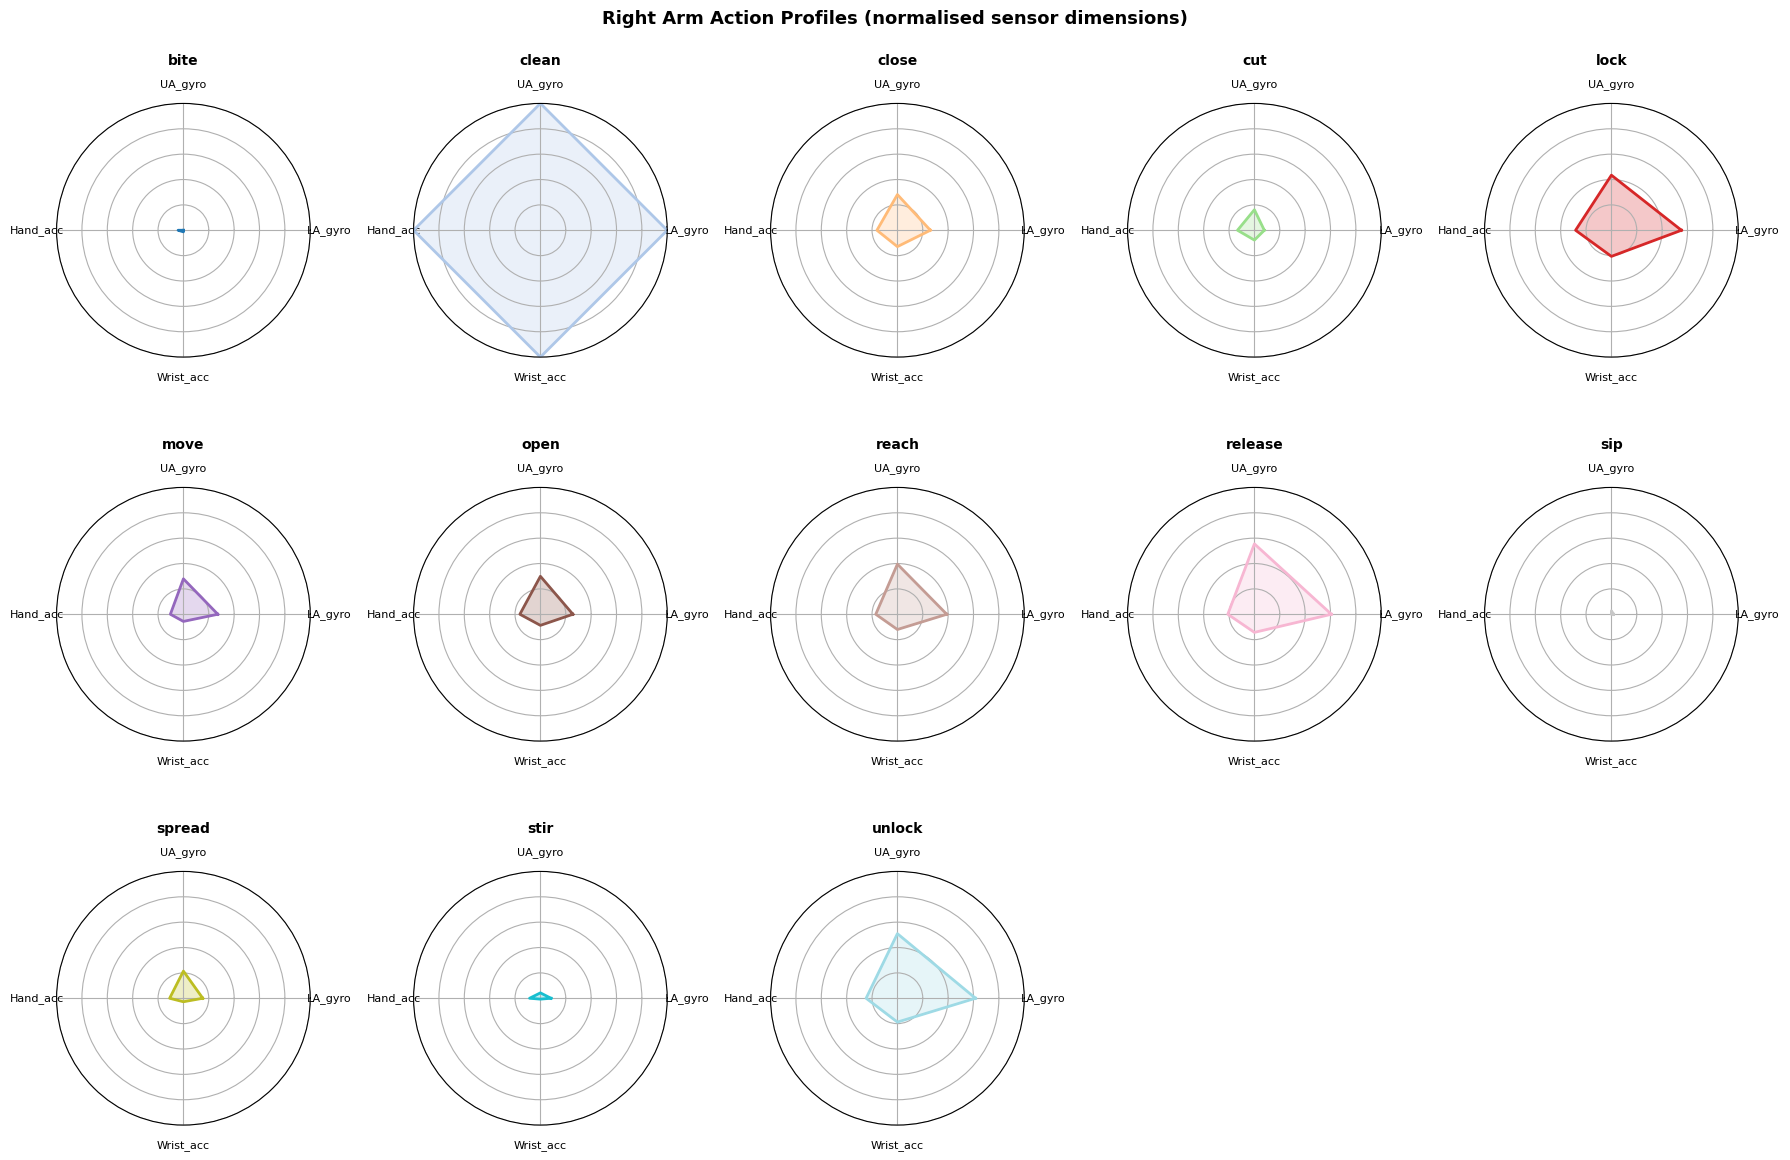

In [12]:
# Radar chart comparing right-arm actions on 4 normalised dimensions:
# 1. Lower-arm gyro magnitude
# 2. Upper-arm gyro magnitude  
# 3. LA/UA ratio (forearm-dominant vs whole-arm)
# 4. Hand acc magnitude (dynamic motion intensity)

rg = df.dropna(subset=['LL_Right_Arm'])
features = {
    'LA_gyro':   rg.groupby('LL_Right_Arm')['R_la_gyro_mag'].mean(),
    'UA_gyro':   rg.groupby('LL_Right_Arm')['R_ua_gyro_mag'].mean(),
    'Hand_acc':  rg.groupby('LL_Right_Arm')['R_hand_acc_mag'].mean(),
    'Wrist_acc': rg.groupby('LL_Right_Arm')['R_wrist_acc_mag'].mean(),
}
feat_df = pd.DataFrame(features)
feat_norm = (feat_df - feat_df.min()) / (feat_df.max() - feat_df.min())

actions = feat_norm.index.tolist()
categories = list(feat_norm.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(3, 5, subplot_kw=dict(polar=True), figsize=(18, 12))
axes = axes.flatten()

colors = plt.cm.tab20(np.linspace(0, 1, len(actions)))

for i, (action, color) in enumerate(zip(actions, colors)):
    ax = axes[i]
    vals = feat_norm.loc[action].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.set_title(action, size=10, fontweight='bold', pad=10)

for j in range(len(actions), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Right Arm Action Profiles (normalised sensor dimensions)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_right_arm.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Consolidated detection rules

The cell below prints the concrete numeric thresholds derived from the data.

In [13]:
def detection_summary(arm_col, la_col, ua_col, la_gyro_prefix, ua_gyro_prefix):
    g = df.dropna(subset=[arm_col])
    summary = g.groupby(arm_col).agg(
        LA_gyro_mean=(la_col, 'mean'),
        LA_gyro_med =(la_col, 'median'),
        LA_gyro_q25 =(la_col, lambda x: x.quantile(0.25)),
        LA_gyro_q75 =(la_col, lambda x: x.quantile(0.75)),
        UA_gyro_mean=(ua_col, 'mean'),
        n           =(la_col, 'count'),
    ).sort_values('LA_gyro_med')

    # Axis fractions for LA
    for ax in ['X','Y','Z']:
        col_abs = f'{la_gyro_prefix}gyro{ax}'
        g2 = g.copy()
        g2[f'abs_{ax}'] = g2[col_abs].abs()
        tot = g2[[f'{la_gyro_prefix}gyro{a}' for a in ['X','Y','Z']]].abs().sum(axis=1)
        g2[f'frac_{ax}'] = g2[f'abs_{ax}'] / tot
        summary[f'LA_frac{ax}'] = g2.groupby(arm_col)[f'frac_{ax}'].mean()

    return summary

print('=== LEFT ARM detection rules ===')
ls = detection_summary(
    'LL_Left_Arm', 'L_la_gyro_mag', 'L_ua_gyro_mag',
    'InertialMeasurementUnit_LLA_', 'InertialMeasurementUnit_LUA_'
)
display(ls.map(lambda x: f'{x:.2f}' if isinstance(x, float) else str(x)))

print('\n=== RIGHT ARM detection rules ===')
rs = detection_summary(
    'LL_Right_Arm', 'R_la_gyro_mag', 'R_ua_gyro_mag',
    'InertialMeasurementUnit_RLA_', 'InertialMeasurementUnit_RUA_'
)
display(rs.map(lambda x: f'{x:.2f}' if isinstance(x, float) else str(x)))

=== LEFT ARM detection rules ===


,LA_gyro_mean,LA_gyro_med,LA_gyro_q25,LA_gyro_q75,UA_gyro_mean,n,LA_fracX,LA_fracY,LA_fracZ
LL_Left_Arm,,,,,,,,,
cut,313.17,145.21,97.18,358.59,277.77,728,0.43,0.23,0.34
sip,281.55,150.91,98.10,267.21,191.97,727,0.44,0.30,0.26
bite,330.81,164.86,94.98,334.00,182.12,3134,0.42,0.28,0.31
move,706.69,491.93,219.35,980.16,584.68,82616,0.36,0.33,0.31
lock,698.37,508.29,316.48,919.58,352.77,70,0.53,0.22,0.24
unlock,1077.12,603.72,429.12,944.19,837.29,54,0.41,0.36,0.23
open,883.61,715.11,404.30,1168.81,814.01,10571,0.38,0.34,0.28
close,918.38,735.20,432.89,1217.02,842.36,10819,0.39,0.34,0.27
reach,1202.13,937.90,496.84,1632.16,952.09,16554,0.41,0.30,0.28



=== RIGHT ARM detection rules ===


,LA_gyro_mean,LA_gyro_med,LA_gyro_q25,LA_gyro_q75,UA_gyro_mean,n,LA_fracX,LA_fracY,LA_fracZ
LL_Right_Arm,,,,,,,,,
bite,220.07,118.75,58.72,241.70,137.07,3804,0.33,0.27,0.40
sip,263.47,163.82,84.09,311.79,191.69,12194,0.44,0.20,0.36
cut,414.87,326.32,194.78,524.65,463.04,9808,0.37,0.33,0.30
stir,428.09,326.64,203.25,519.46,222.82,4536,0.49,0.27,0.23
spread,600.94,510.59,319.46,758.45,568.37,5374,0.36,0.36,0.28
open,859.27,663.97,380.65,1111.16,740.01,15778,0.34,0.33,0.33
close,867.98,678.81,404.79,1089.06,703.89,14536,0.39,0.28,0.33
move,896.32,704.11,347.10,1260.91,699.85,113108,0.34,0.32,0.33
reach,1190.50,922.02,500.18,1600.45,933.14,35030,0.38,0.30,0.32


---
# Analysis Results: How to Detect Arm Actions from Sensors

## Primary sensor: lower-arm IMU gyroscope magnitude

**Sensor columns:**  
- Left arm: `InertialMeasurementUnit_LLA_gyroX/Y/Z`  
- Right arm: `InertialMeasurementUnit_RLA_gyroX/Y/Z`  

Compute: **gyro_mag = √(gyroX² + gyroY² + gyroZ²)**

---

## Action-by-action physical explanation

### 🟢 Very Low rotation (gyro_mag < ~300 deg/s)

| Action | Right arm median | Left arm median | Key physical signature |
|--------|-----------------|-----------------|------------------------|
| **sip** | ~263 | ~282 | Arm raised and held still at mouth height. Cup/glass contact. Forearm barely rotates — the arm is stationary while swallowing. The hand accelerometer shows elevated positive-Z (forearm tilted upward toward mouth). |
| **bite** | ~220 | ~145 | Similar posture to sip. The arm is extended and held stable while the subject bites into food. Lower gyro than sip because the arm may even be resting on a surface. |
| **stir** (right only) | ~428 | N/A | Circular wrist/forearm motion, but small amplitude. The **X axis of the right lower-arm gyro** is dominant (pronation-supination: the forearm twists back and forth around its long axis). The upper-arm barely moves; the LA/UA ratio is high. |

**Detection:** `gyro_mag < 350` on the lower-arm IMU. Distinguish sip/bite using object sensors (cup/glass accelerometers elevated during sip) and arm posture (hand accZ positive, hand accY strongly negative during mouth-contact actions).

---

### 🟡 Low-Medium rotation (gyro_mag ~350–650 deg/s)

| Action | Right arm median | Left arm median | Key physical signature |
|--------|-----------------|-----------------|------------------------|
| **cut** | ~414 | ~313 | Short back-and-forth knife strokes. The forearm moves in a push-pull pattern, producing moderate rotation across X and Z axes. Upper arm is mostly stable (LA/UA ratio > 1). Object sensor on KNIFE1 or KNIFE2 shows elevated motion. |
| **spread** (right only) | ~600 | N/A | Spreading with a knife or spoon: similar short strokes to cut but more lateral (Y-axis dominant). The wrist moves more than the elbow. KNIFE or SPOON object sensors are active. |
| **move** | ~896 | ~706 | Arm transporting an object from one place to another. Sustained moderate gyro across all axes as the whole arm sweeps through space. The upper arm contributes substantially (LA/UA ratio ~1.3–1.6). |

**Detection:** `350 < gyro_mag < 700`. Distinguish cut/spread from move by the LA/UA ratio (cut/spread: LA >> UA; move: LA ≈ UA) and duration (move is sustained; cut/spread are shorter bursts).

---

### 🟠 Medium-High rotation (gyro_mag ~700–1100 deg/s)

| Action | Right arm median | Left arm median | Key physical signature |
|--------|-----------------|-----------------|------------------------|
| **open** | ~859 | ~884 | Pulling open a door, drawer, or fridge. The arm extends and rotates from the shoulder, sweeping outward. The upper arm contributes significantly. Reed switches on the target object transition from 1→0 (or change value), confirming the opening event. |
| **close** | ~868 | ~918 | Mirror of open: arm pushes in, rotating at the shoulder. Reed switch values on the target object transition toward closed (0→1). |

**Detection:** `700 < gyro_mag < 1100`. Confirm open/close by monitoring reed switches (FRIDGE, MIDDLEDRAWER, UPPERDRAWER, LOWERDRAWER, DISHWASHER) for state changes concurrent with high gyro. The direction of the state change (0→1 = close; 1→0 = open) disambiguates the two. Object accelerometers on the door/drawer also spike.

---

### 🔴 High rotation (gyro_mag > 1100 deg/s)

| Action | Right arm median | Left arm median | Key physical signature |
|--------|-----------------|-----------------|------------------------|
| **reach** | ~1190 | ~1202 | The arm swings outward from the body to grasp an object — a large ballistic movement involving the entire arm. Both upper and lower arm rotate at comparable rates (LA/UA ratio ~1.3). Acceleration magnitude also rises notably (hand/wrist). |
| **release** | ~1734 | ~1560 | After placing or dropping an object, the arm swings back or retracts rapidly. This is characteristically the highest-gyro "settling" motion — the arm accelerates away from the object without controlled deceleration. |
| **lock/unlock** | ~1597/~1756 | ~698/~1077 | Turning a key or switch: strong **X-axis dominance** in the lower-arm gyro (forearm supination/pronation). The upper arm stays relatively still while the forearm twists. These are brief but intense bursts. Right arm shows higher activity than left (dominant hand handles the mechanism). |
| **clean** | ~2713 | ~2373 | Table scrubbing: a highly repetitive, vigorous back-and-forth motion with the whole arm. The **Y axis of the lower-arm gyro** is dominant (lateral sweep). Both upper and lower arm rotate at very high and comparable rates — the whole arm is engaged. This produces by far the highest gyro values in the dataset. |

**Detection:**  
- `gyro_mag > 1100` → reach/release/lock/unlock/clean  
- **clean**: `gyro_mag > 2000` (sustained, not a brief burst; Y-axis dominant in LA gyro)  
- **lock/unlock**: X-axis dominance in LA gyro (`fracX > 0.45`), brief duration, right arm more active  
- **reach vs. release**: reach precedes object contact (object accelerometers spike *after* reach ends); release follows placement (arm motion *away* from where it just was)

---

## Left arm vs. Right arm asymmetry

The subjects are predominantly **right-handed**, which creates systematic asymmetries:

| Pattern | Explanation |
|---------|-------------|
| **Right arm consistently higher gyro** than left for same-named action | The right arm is the active/dominant arm performing the task; the left arm often assists or stabilizes. |
| **Right arm has unique actions**: stir, spread | These fine-motor tasks (stirring coffee, spreading butter) are exclusively performed with the dominant hand while the left holds the container or bread. |
| **Left arm "bite" has lower gyro** than right arm "bite" | When biting, the right arm brings the food to the mouth (higher motion); the left arm holds/positions the other portion (lower, steadying motion). |
| **Left arm "sip" lower than right** | The right (dominant) hand holds and raises the cup; left arm rests. |
| **Left arm "reach" is comparable to right** | Reaching is a large motor action both arms execute similarly regardless of handedness. |
| **Left arm "clean" is nearly as vigorous as right** | Scrubbing requires full engagement of both arms (one may use a cloth, one the surface). |

---

## Supplementary sensors: hand accelerometer axes (arm posture)

**Sensor columns:**  
- Left hand: `Accelerometer_LH_accX/Y/Z`  
- Right hand: `Accelerometer_RH_accX/Y/Z`

The mean signed accelerometer values encode the **gravity direction relative to the hand** and therefore the arm's typical posture:

| Action | Left hand accY | Right hand accY | Interpretation |
|--------|---------------|-----------------|----------------|
| sip | −354 | −618 | Strongly negative: hand/forearm is tilted *downward* relative to the sensor mounting, meaning the arm is elevated (bent at elbow, forearm pointing up toward face). |
| bite | −663 | −640 | Similar to sip: arm raised toward mouth. |
| clean | +726 | +550 | Positive: forearm sweeping forward/laterally along the table surface. |
| reach/open/close | +500–700 | +400–460 | Positive: arm extended forward and upward. |
| cut | +253 | +355 | Moderate positive: arm positioned at table level, pushing forward. |

**Key rule:** `accY < -300` (hand sensor) → arm is raised toward the face → consistent with sip or bite.

---

## Recommended detection pipeline

```
1. Compute lower-arm gyroscope magnitude (LA_gyro) from IMU_LLA/RLA gyroX/Y/Z.

2. TIER 1 – Magnitude thresholds:
   - LA_gyro < 350        → candidate: {sip, bite, stir(R)}
   - 350 ≤ LA_gyro < 700  → candidate: {cut, spread(R), move}
   - 700 ≤ LA_gyro < 1100 → candidate: {open, close, move}
   - LA_gyro ≥ 1100       → candidate: {reach, release, lock, unlock, clean}

3. TIER 2 – Refine with axis dominance (LA gyro fraction per axis):
   - fracX > 0.45 and LA_gyro > 1000 → lock or unlock
   - fracY > 0.40 and LA_gyro > 2000 → clean
   - fracX > 0.43 and LA_gyro < 350  → sip (or bite)
   - fracX > 0.43 and LA_gyro < 350 (right arm only) → stir if motion is repetitive

4. TIER 3 – Confirm with posture (hand accelerometer accY):

   - accY > +400 → open, close, clean, reach (arm extended forward)

5. TIER 4 – Confirm with object sensors:
   - Reed switch transition 1→0 during high gyro → open
   - Reed switch transition 0→1 during high gyro → close
   - Cup/glass accelerometer elevated → sip
   - Knife accelerometer elevated → cut or spread
   - Spoon accelerometer elevated → stir
```